## Ejercicio 1

Implemente un algoritmo de optimización por enjambre de partículas y utilícelo para encontrar el mínimo global de las funciones del Ejercicio 1 de la Guía de trabajos prácticos 6.

Compare los resultados en relación a los obtenidos con algoritmos genéticos, en términos de las soluciones encontradas y la velocidad de convergencia.

**Inciso 1**: $f(x) = -x \sin\left(\sqrt{|x|}\right), \quad -512 \leq x \leq 512$

In [1]:
#TODO

**Inciso 2**: $f(x, y) = (x^2 + y^2)^{0.25} \left[\sin^2\left(50(x^2+y^2)^{0.1}\right) + 1\right], \quad -100 \leq x, y \leq 100$

In [2]:
#TODO

## Ejercicio 2

Suponga que un viajante tiene que visitar $n$ ciudades en el menor tiempo posible. Considere una matriz $D$ de tamaño $n \times n$ cuyos elementos $d_{pq}$ denotan la distancia entre cada par de ciudades $(p, q)$. Se define un *recorrido* como una trayectoria *cerrada* que visita cada ciudad una y sólo una vez (a excepción de la ciudad de partida, a la cual debe regresar). El problema consiste en hallar el recorrido de mínima longitud.

Implemente el algoritmo de sistema de hormigas y utilícelo para resolver el problema del agente viajero considerando los datos proporcionados en el archivo `gr17.csv`.

Analice el efecto de la *tasa de evaporación* ($\rho$) y de la *cantidad de feromona depositada* ($\tau$) sobre los resultados de la búsqueda. Para esto último compare el desempeño del algoritmo empleando los métodos *global*, *local* y *uniforme* para depósito de feromonas. Realice varias corridas con cada configuración experimental y considere el tiempo de búsqueda y la longitud de los caminos encontrados como medidas para comparar el desempeño. Construya una tabla comparativa con los resultados obtenidos.

### Idea del sistema de hormigas

Cada hormiga arma un recorrido completo eligiendo de a una ciudad. Al final de cada iteración las conexiones usadas reciben feromona, y en la iteración siguiente son más probables.

```mermaid
flowchart TD
    A["Feromonas iniciales chicas y al azar"] --> B["Cada hormiga arranca en una ciudad al azar"]
    B --> C["Elegir la próxima ciudad por ruleta<br/>(sólo entre las no visitadas)"]
    C --> D{"¿Visitó todas?"}
    D -- No --> C
    D -- Sí --> E["Volver a la primera y calcular el largo"]
    E --> F["Evaporar en todas las conexiones"]
    F --> G["Depositar en las conexiones usadas<br/>(global, uniforme o local)"]
    G --> H{"¿Todas hicieron el mismo camino<br/>o llegué al máximo de iteraciones?"}
    H -- No --> B
    H -- Sí --> Z(["Fin: el recorrido más corto encontrado"])
```

- **Probabilidad de ir de $i$ a $j$**: proporcional a $\sigma_{ij}^\alpha \, \eta_{ij}^\beta$, donde $\sigma_{ij}$ es la feromona de la conexión y $\eta_{ij} = 1/d_{ij}$ es el *deseo* (las ciudades cercanas atraen más). Las ciudades ya visitadas tienen probabilidad 0 (lista tabú).
- **Evaporación**: $\sigma_{ij} \leftarrow (1 - \rho)\, \sigma_{ij}$ en todas las conexiones.
- **Depósito**: cada hormiga $k$ suma $\Delta\sigma_{ij}^k$ en cada tramo $(i, j)$ de su recorrido:

| Método | $\Delta\sigma_{ij}^k$ | Qué premia |
|---|---|---|
| Global | $Q / L_k$ | que el recorrido completo sea corto |
| Uniforme | $Q$ | sólo que la hormiga pasó por ahí |
| Local | $Q / d_{ij}$ | que ese tramo sea corto |

El recorrido óptimo de `gr17` mide **2085** (es un problema de la biblioteca TSPLIB).

In [3]:
import csv
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

#leo la matriz de distancias: la fila p, columna q es la distancia entre las ciudades p y q
distancias = []
with open("gr17.csv") as archivo:
    for fila in csv.reader(archivo):
        valores = []
        for v in fila:
            valores.append(float(v))
        distancias.append(valores)

n_ciudades = len(distancias)
print("ciudades:", n_ciudades)
print("distancias desde la ciudad 0:", distancias[0])

ciudades: 17
distancias desde la ciudad 0: [0.0, 633.0, 257.0, 91.0, 412.0, 150.0, 80.0, 134.0, 259.0, 505.0, 353.0, 324.0, 70.0, 211.0, 268.0, 246.0, 121.0]


In [4]:
#largo de un recorrido cerrado: sumo cada tramo y al final vuelvo a la ciudad de partida
def longitud(recorrido):
    total = 0
    for i in range(len(recorrido) - 1):
        total = total + distancias[recorrido[i]][recorrido[i + 1]]
    total = total + distancias[recorrido[-1]][recorrido[0]]
    return total

#feromonas iniciales: valores chicos al azar entre 0 y sigma0
def inicializar_feromonas(sigma0):
    feromonas = []
    for i in range(n_ciudades):
        fila = []
        for j in range(n_ciudades):
            fila.append(random.uniform(0, sigma0))
        feromonas.append(fila)
    return feromonas

#la hormiga esta en "actual" y elige la proxima ciudad entre las que todavia no visito (lista tabu)
#cada candidata tiene un peso feromona^alfa * (1/distancia)^beta, y se elige por ruleta
def elegir_siguiente(actual, visitadas, feromonas, alfa, beta):
    candidatas = []
    pesos = []
    for j in range(n_ciudades):
        if j not in visitadas:
            deseo = 1 / distancias[actual][j]
            candidatas.append(j)
            pesos.append(feromonas[actual][j] ** alfa * deseo ** beta)

    #ruleta: tiro un numero entre 0 y la suma de los pesos y veo en que porcion cae
    tiro = random.uniform(0, sum(pesos))
    acumulado = 0
    for i in range(len(candidatas)):
        acumulado = acumulado + pesos[i]
        if tiro <= acumulado:
            return candidatas[i]
    return candidatas[-1]

#una hormiga arranca en una ciudad al azar y va eligiendo hasta visitarlas todas
def construir_recorrido(feromonas, alfa, beta):
    actual = random.randrange(n_ciudades)
    recorrido = [actual]
    while len(recorrido) < n_ciudades:
        actual = elegir_siguiente(actual, recorrido, feromonas, alfa, beta)
        recorrido.append(actual)
    return recorrido

#evaporacion: en TODAS las conexiones queda (1 - rho) de lo que habia
def evaporar(feromonas, rho):
    for i in range(n_ciudades):
        for j in range(n_ciudades):
            feromonas[i][j] = (1 - rho) * feromonas[i][j]

#deposito: cada hormiga deja feromona en los tramos que uso
#  global:   Q / largo del recorrido completo
#  uniforme: Q
#  local:    Q / distancia del tramo
def depositar(feromonas, recorridos, metodo, Q):
    for recorrido in recorridos:
        largo = longitud(recorrido)
        for i in range(n_ciudades):
            p = recorrido[i]
            q = recorrido[(i + 1) % n_ciudades]     #el ultimo tramo vuelve a la ciudad de partida

            if metodo == "global":
                cantidad = Q / largo
            if metodo == "uniforme":
                cantidad = Q
            if metodo == "local":
                cantidad = Q / distancias[p][q]

            #la matriz es simetrica: ir de p a q es lo mismo que ir de q a p
            feromonas[p][q] = feromonas[p][q] + cantidad
            feromonas[q][p] = feromonas[q][p] + cantidad

#conjunto de tramos de un recorrido, sin importar el sentido ni la ciudad de partida
#sirve para saber si dos hormigas hicieron el mismo camino
def tramos(recorrido):
    conjunto = set()
    for i in range(n_ciudades):
        p = recorrido[i]
        q = recorrido[(i + 1) % n_ciudades]
        conjunto.add((min(p, q), max(p, q)))
    return conjunto

In [5]:
def sistema_de_hormigas(metodo, rho, Q=1, n_hormigas=10, alfa=1, beta=1, sigma0=0.1, max_iteraciones=200):
    inicio = time.time()
    feromonas = inicializar_feromonas(sigma0)
    mejor = None
    mejor_largo = float("inf")
    historia = []       #mejor largo encontrado hasta cada iteracion, para graficar

    for iteracion in range(1, max_iteraciones + 1):

        #1. cada hormiga construye su recorrido
        recorridos = []
        for k in range(n_hormigas):
            recorridos.append(construir_recorrido(feromonas, alfa, beta))

        #2. guardo el mejor recorrido visto hasta ahora
        for recorrido in recorridos:
            if longitud(recorrido) < mejor_largo:
                mejor_largo = longitud(recorrido)
                mejor = recorrido
                iteracion_mejor = iteracion                 #en que iteracion lo encontre
                tiempo_mejor = time.time() - inicio         #y cuanto tarde en encontrarlo
        historia.append(mejor_largo)

        #3. actualizo feromonas: primero evaporo en todas, despues deposito en las usadas
        evaporar(feromonas, rho)
        depositar(feromonas, recorridos, metodo, Q)

        #4. termino si todas las hormigas hicieron el mismo camino
        todas_iguales = True
        for recorrido in recorridos:
            if tramos(recorrido) != tramos(recorridos[0]):
                todas_iguales = False
        if todas_iguales:
            break

    return mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor

### Experimentos

Pruebo los 3 métodos de depósito con 4 tasas de evaporación, 10 corridas por configuración. Los demás parámetros quedan fijos: 10 hormigas, $\alpha = 1$, $\beta = 1$, $Q = 1$ y como máximo 200 iteraciones.

- **Largo**: el mejor recorrido de cada corrida (óptimo = 2085).
- **Tiempo de búsqueda**: segundos e iteraciones hasta encontrar ese mejor recorrido.

Uso $\beta = 1$ porque con $\beta = 2$ el deseo $1/d$ pesa tanto que todas las configuraciones llegan al óptimo y no se ve el efecto de $\rho$ ni del depósito.

In [6]:
metodos = ["global", "uniforme", "local"]
tasas = [0.01, 0.1, 0.5, 0.9]
corridas = 10
OPTIMO = 2085

filas = []
historias = {}      #historias[(metodo, rho)] = lista con la historia de cada corrida

for metodo in metodos:
    for rho in tasas:
        largos = []
        iteraciones = []
        tiempos = []
        historias[(metodo, rho)] = []

        for corrida in range(corridas):
            random.seed(corrida)
            mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor = sistema_de_hormigas(metodo, rho)
            largos.append(mejor_largo)
            iteraciones.append(iteracion_mejor)
            tiempos.append(tiempo_mejor)
            historias[(metodo, rho)].append(historia)

        filas.append([metodo, rho, min(largos), sum(largos) / corridas, max(largos),
                      str(largos.count(OPTIMO)) + "/" + str(corridas),
                      sum(iteraciones) / corridas, sum(tiempos) / corridas])

tabla = pd.DataFrame(filas, columns=["depósito", "ρ", "mejor largo", "largo promedio", "peor largo",
                                     "llegó al óptimo", "iteraciones promedio", "tiempo promedio (s)"])
tabla.round(2)

,depósito,ρ,mejor largo,largo promedio,peor largo,llegó al óptimo,iteraciones promedio,tiempo promedio (s)
0,global,0.01,2160.0,2242.3,2287.0,0/10,157.6,0.33
1,global,0.10,2085.0,2102.3,2132.0,2/10,165.8,0.35
2,global,0.50,2085.0,2107.8,2149.0,1/10,120.6,0.26
3,global,0.90,2085.0,2121.6,2160.0,1/10,82.3,0.17
4,uniforme,0.01,2085.0,2124.8,2173.0,1/10,128.9,0.29
5,uniforme,0.10,2085.0,2104.4,2152.0,4/10,145.1,0.30
6,uniforme,0.50,2085.0,2116.6,2158.0,1/10,103.0,0.21
7,uniforme,0.90,2085.0,2124.3,2167.0,1/10,125.1,0.27
8,local,0.01,2085.0,2093.4,2115.0,4/10,129.7,0.27
9,local,0.10,2085.0,2091.3,2105.0,5/10,81.9,0.17


### Efecto de la tasa de evaporación

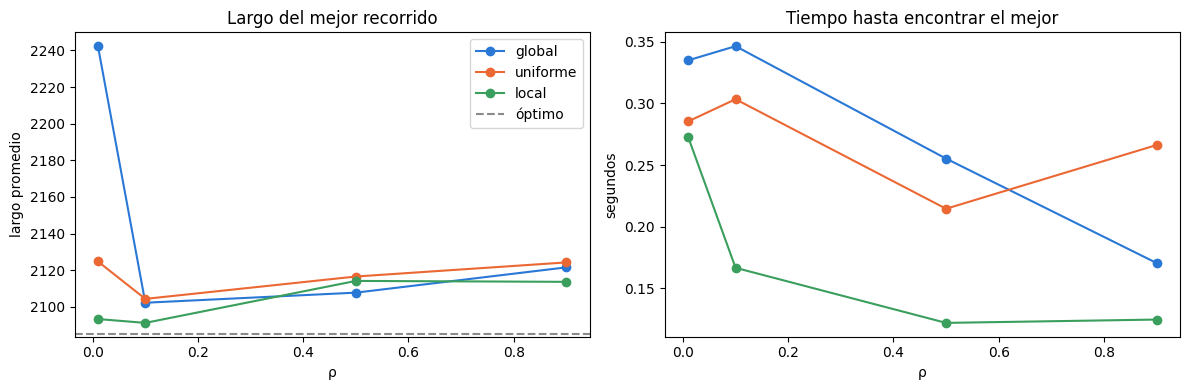

In [7]:
COLORES = {"global": "#2a78d6", "uniforme": "#eb6834", "local": "#3a9e5c"}

#largo promedio segun rho, una linea por metodo
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for metodo in metodos:
    largos_promedio = []
    tiempos_promedio = []
    for fila in filas:
        if fila[0] == metodo:
            largos_promedio.append(fila[3])
            tiempos_promedio.append(fila[7])
    ejes[0].plot(tasas, largos_promedio, "o-", color=COLORES[metodo], label=metodo)
    ejes[1].plot(tasas, tiempos_promedio, "o-", color=COLORES[metodo], label=metodo)

ejes[0].axhline(OPTIMO, color="#8a8a8a", linestyle="--", label="óptimo")
ejes[0].set_xlabel("ρ")
ejes[0].set_ylabel("largo promedio")
ejes[0].set_title("Largo del mejor recorrido")
ejes[1].set_xlabel("ρ")
ejes[1].set_ylabel("segundos")
ejes[1].set_title("Tiempo hasta encontrar el mejor")
ejes[0].legend()
plt.tight_layout()
plt.show()

### Comparación de los métodos de depósito

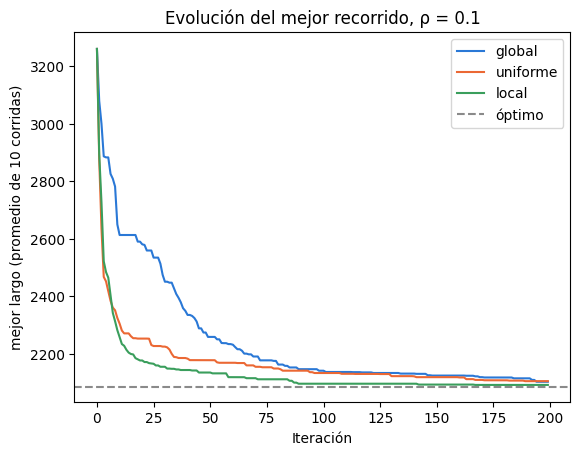

In [8]:
#evolucion del mejor largo con rho = 0.1: promedio de las 10 corridas para cada metodo
rho = 0.1
for metodo in metodos:
    promedio = []
    for it in range(len(historias[(metodo, rho)][0])):
        suma = 0
        for historia in historias[(metodo, rho)]:
            suma = suma + historia[it]
        promedio.append(suma / corridas)
    plt.plot(promedio, color=COLORES[metodo], label=metodo)

plt.axhline(OPTIMO, color="#8a8a8a", linestyle="--", label="óptimo")
plt.xlabel("Iteración")
plt.ylabel("mejor largo (promedio de 10 corridas)")
plt.title("Evolución del mejor recorrido, ρ = " + str(rho))
plt.legend()
plt.show()

In [9]:
#una corrida de ejemplo: el recorrido que encontró (vuelve a la ciudad de partida)
random.seed(0)
mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor = sistema_de_hormigas("local", 0.1)
print("recorrido:", mejor + [mejor[0]])
print("largo:", mejor_largo)

recorrido: [8, 11, 15, 0, 3, 12, 6, 16, 7, 5, 13, 14, 2, 10, 9, 1, 4, 8]
largo: 2095.0


### Conclusiones

- **Tasa de evaporación.** El mejor valor fue $\rho = 0.1$ en los tres métodos. Con $\rho = 0.01$ lo que se depositó al principio (y las feromonas iniciales al azar) casi no se borra, y la colonia sigue reforzando caminos malos: es el peor caso, sobre todo con depósito global. Con $\rho$ grande (0.5 y 0.9) la colonia encuentra su mejor recorrido en menos iteraciones, pero ese recorrido es más largo: se olvida todo enseguida y no aprovecha lo aprendido (convergencia prematura).
- **Método de depósito.** El **local** fue el mejor: menor largo promedio (2091 con $\rho = 0.1$), llegó al óptimo en 5 de 10 corridas y fue el más rápido (82 iteraciones en promedio). Premia los tramos cortos, que es justamente lo que forma un buen recorrido. **Global** y **uniforme** terminan parecido, pero el global arranca más lento: con $Q = 1$ deposita $1/L \approx 0.0005$ por tramo, mucho menos que las feromonas iniciales (hasta 0.1), y tarda en imponerse. El uniforme deposita lo mismo para un recorrido bueno que para uno malo.
- **Tiempo.** Todas las corridas tardan menos de medio segundo. En ninguna todas las hormigas terminaron haciendo el mismo camino, así que siempre cortó por el máximo de iteraciones; por eso el tiempo de búsqueda se midió hasta encontrar el mejor recorrido.